In [90]:
from TC import TC
import numpy as np
import pandas as pd
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt

In [91]:
CATEGORICAL_FILE = r"../data/drug_consumption_transformed.csv"

PRED_CAT_FILE = r"../data/Logistic/multinomial_pred_cat.csv"
PRED_NUM_FILE = r"../data/Logistic/multinomial_pred_num.csv"

OUTPUT_CAT_PLOT = r"../plots/multinomial_logistic_TC_cat.png"
OUTPUT_NUM_PLOT = r"../plots/multinomial_logistic_TC_num.png"

HYPERPARAMETER_SPACE = r"../data/Logistic/multinomial_tuning_cat.csv"

df_cat = pd.read_csv(CATEGORICAL_FILE)
true_values = df_cat["choc"].str[2].astype(int)

n = len(true_values)

In [92]:
df_hyp = pd.read_csv(HYPERPARAMETER_SPACE)[["alpha","lambda"]]
df_hyp

,alpha,lambda
0,0.0,100.0000
1,0.1,100.0000
2,0.2,100.0000
3,0.3,100.0000
4,0.4,100.0000
...,...,...
138,0.6,0.0001
139,0.7,0.0001
140,0.8,0.0001
141,0.9,0.0001


In [93]:
pred_cat = pd.read_csv(PRED_CAT_FILE).merge(df_hyp, left_index=True, right_index=True)
pred_num = pd.read_csv(PRED_NUM_FILE).merge(df_hyp, left_index=True, right_index=True)

In [94]:
def calculate_TC(group):
    C = confusion_matrix(group.values[0][:n], true_values)
    return TC(C)

In [95]:
TC_cat = pred_cat.groupby(["lambda", "alpha"]).apply(calculate_TC, include_groups=False).reset_index(name = "TC")
TC_num = pred_num.groupby(["lambda", "alpha"]).apply(calculate_TC, include_groups=False).reset_index(name = "TC")

TC_cat_pivot = TC_cat.pivot(index = "lambda", columns = "alpha", values = "TC")
TC_num_pivot = TC_num.pivot(index = "lambda", columns = "alpha", values = "TC")

In [96]:
alpha_min_cat = TC_cat.nsmallest(1, "TC").iloc[0].alpha
lambda_min_cat = TC_cat.nsmallest(1, "TC").iloc[0]["lambda"]
TC_min_cat = TC_cat.nsmallest(1, "TC").iloc[0].TC
alpha_min_num = TC_num.nsmallest(1, "TC").iloc[0].alpha
lambda_min_num = TC_num.nsmallest(1, "TC").iloc[0]["lambda"]
TC_min_num = TC_num.nsmallest(1, "TC").iloc[0].TC

pred_min_cat = pred_cat[(pred_cat.alpha == alpha_min_cat) & (pred_cat["lambda"] == lambda_min_cat)].values[0][:n]
C_min_cat = confusion_matrix(pred_min_cat, true_values)
pred_min_num = pred_num[(pred_num.alpha == alpha_min_num) & (pred_num["lambda"] == lambda_min_num)].values[0][:n]
C_min_num = confusion_matrix(pred_min_num, true_values)


alpha_min_cat, lambda_min_cat, TC_min_cat, C_min_cat, alpha_min_num, lambda_min_num, TC_min_num, C_min_num

(0.6,
 0.0031622776601683,
 2995.503494339452,
 array([[  0,   0,   0,   0,   0,   0,   0],
        [  0,   0,   0,   0,   0,   0,   0],
        [  0,   0,   0,   0,   0,   0,   0],
        [  0,   0,   0,   0,   0,   0,   0],
        [  0,   0,   0,   0,   1,   4,   2],
        [ 10,   1,   3,  14,  95, 140, 154],
        [ 22,   2,   7,  40, 200, 539, 651]], dtype=int64),
 0.1,
 0.0316227766016838,
 2972.1685497117073,
 array([[  0,   0,   0,   0,   0,   0,   0],
        [  0,   0,   0,   0,   0,   0,   0],
        [  0,   0,   0,   0,   0,   0,   0],
        [  0,   0,   0,   0,   0,   0,   0],
        [  0,   0,   1,   0,   1,   0,   0],
        [  8,   2,   2,  10,  94, 133, 141],
        [ 24,   1,   7,  44, 201, 550, 666]], dtype=int64))

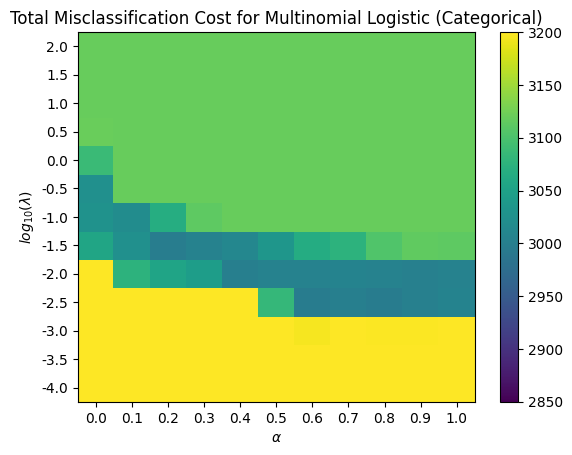

In [97]:
plt.pcolor(TC_cat_pivot, vmin = 2850, vmax = 3200, cmap = "viridis")
plt.xticks(np.arange(len(TC_cat_pivot.columns))+0.5, TC_cat_pivot.columns)
plt.yticks(np.arange(len(TC_cat_pivot.index))+0.5, np.log10(TC_cat_pivot.index).round(1))
plt.ylabel(r"$log_{10}(\lambda)$")
plt.xlabel(r"$\alpha$")
plt.title("Total Misclassification Cost for Multinomial Logistic (Categorical)")
plt.colorbar()

plt.savefig(OUTPUT_CAT_PLOT, dpi = 300)

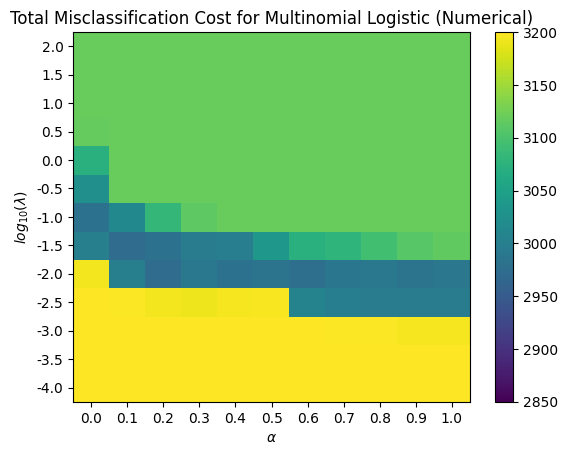

In [98]:
plt.pcolor(TC_num_pivot, vmin = 2850, vmax = 3200, cmap = "viridis")
plt.xticks(np.arange(len(TC_num_pivot.columns))+0.5, TC_num_pivot.columns)
plt.yticks(np.arange(len(TC_num_pivot.index))+0.5, np.log10(TC_num_pivot.index).round(1))
plt.ylabel(r"$log_{10}(\lambda)$")
plt.xlabel(r"$\alpha$")
plt.title("Total Misclassification Cost for Multinomial Logistic (Numerical)")
plt.colorbar()

plt.savefig(OUTPUT_NUM_PLOT, dpi = 300)